In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [2]:
DATASET_PATH = r"C:\Users\P.Srikar\Downloads\FINAL_DATASET"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50

In [3]:
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 9760 images belonging to 2 classes.
Found 2440 images belonging to 2 classes.


In [4]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights))

In [5]:
base_model = MobileNetV3Large(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # Phase 1: freeze
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
output = Dense(2, activation="softmax")(x)
model = Model(inputs=base_model.input, outputs=output)

In [6]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ activation[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        256 │ re_lu[0][0]       │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_add   │ (None, 112, 112,  │          0 │ activation[0][0], │
│ (Add)               │ 16)               │            │ expanded_conv_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │      1,024 │ expanded_conv_ad… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ expanded_conv_1_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 113, 113,  │          0 │ re_lu_1[0][0]     │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        576 │ expanded_conv_1_… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        256 │ expanded_conv_1_

 Total params: 3,277,058 (12.50 MB)

 Trainable params: 279,938 (1.07 MB)

 Non-trainable params: 2,997,120 (11.43 MB)

In [7]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    "best_heart_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [8]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 696s 2s/step - accuracy: 0.7406 - loss: 0.5845 - val_accuracy: 0.9209 - val_loss: 0.2347
Epoch 2/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 581s 2s/step - accuracy: 0.8556 - loss: 0.3437 - val_accuracy: 0.9090 - val_loss: 0.2212
Epoch 3/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 538s 2s/step - accuracy: 0.8911 - loss: 0.2653 - val_accuracy: 0.9061 - val_loss: 0.2274
Epoch 4/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 488s 2s/step - accuracy: 0.9028 - loss: 0.2317 - val_accuracy: 0.9217 - val_loss: 0.1975
Epoch 5/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 486s 2s/step - accuracy: 0.9243 - loss: 0.1947 - val_accuracy: 0.9172 - val_loss: 0.2044
Epoch 6/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 475s 2s/step - accuracy: 0.9252 - loss: 0.1825 - val_accuracy: 0.9234 - val_loss: 0.1875
Epoch 7/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 501s 2s/step - accuracy: 0.9362 - loss: 0.1603 - val_accuracy: 0.9197 - val_loss: 0.1884
Epoch 8/50
305/305 ━━━━━━━━━━━━━━━━━━━━ 475s 2s/step - accuracy: 0.9391 - loss: 0.1499 - val_accu

In [9]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
model.compile(
    optimizer=Adam(learning_rate=1e-5),  # lower LR
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 569s 2s/step - accuracy: 0.9252 - loss: 0.1911 - val_accuracy: 0.9086 - val_loss: 0.2293
Epoch 2/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 522s 2s/step - accuracy: 0.9355 - loss: 0.1633 - val_accuracy: 0.9127 - val_loss: 0.2271
Epoch 3/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 511s 2s/step - accuracy: 0.9391 - loss: 0.1538 - val_accuracy: 0.9266 - val_loss: 0.1886
Epoch 4/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 497s 2s/step - accuracy: 0.9511 - loss: 0.1215 - val_accuracy: 0.9324 - val_loss: 0.1660
Epoch 5/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 499s 2s/step - accuracy: 0.9530 - loss: 0.1228 - val_accuracy: 0.9262 - val_loss: 0.1840
Epoch 6/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 504s 2s/step - accuracy: 0.9577 - loss: 0.1101 - val_accuracy: 0.9426 - val_loss: 0.1457
Epoch 7/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 554s 2s/step - accuracy: 0.9592 - loss: 0.1043 - val_accuracy: 0.9463 - val_loss: 0.1361
Epoch 8/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 536s 2s/step - accuracy: 0.9645 - loss: 0.0918 - val_accu

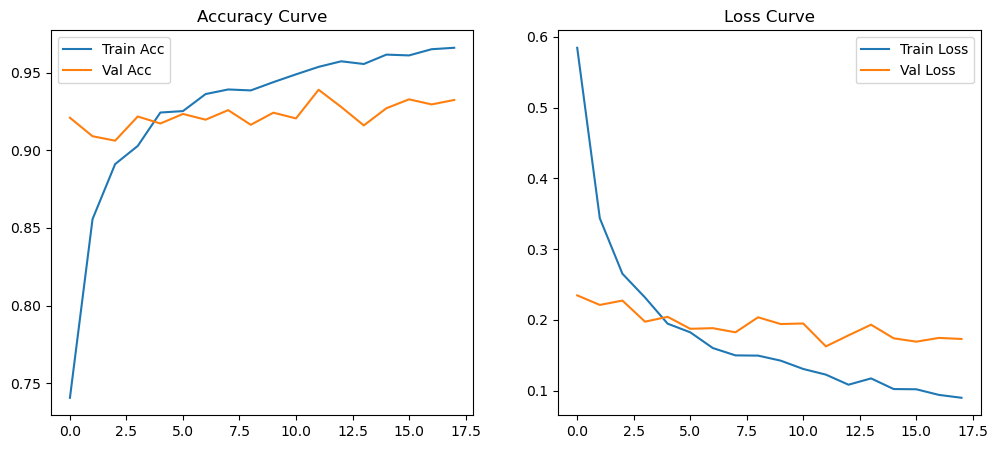

In [10]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

77/77 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step


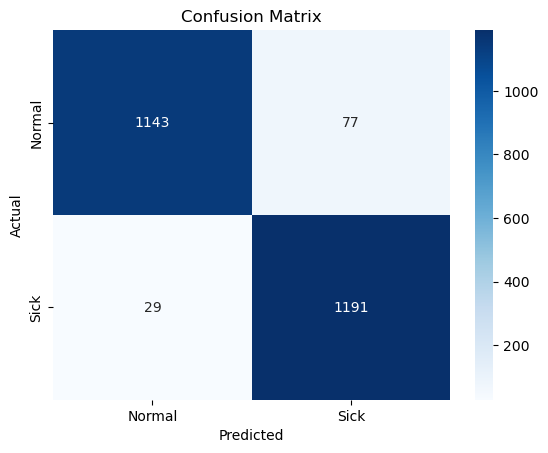

              precision    recall  f1-score   support

      Normal       0.98      0.94      0.96      1220
        Sick       0.94      0.98      0.96      1220

    accuracy                           0.96      2440
   macro avg       0.96      0.96      0.96      2440
weighted avg       0.96      0.96      0.96      2440



In [11]:
y_pred_prob = model.predict(val_gen)
y_pred = np.argmax(y_pred_prob, axis=1)
true_labels = val_gen.classes
cm = confusion_matrix(true_labels, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=val_gen.class_indices.keys(),
    yticklabels=val_gen.class_indices.keys()
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
print(classification_report(
    true_labels,
    y_pred,
    target_names=val_gen.class_indices.keys()
))

y_true length: 2440
y_pred length: 2440
y_true shape: (2440, 2)
y_pred shape: (2440, 2)


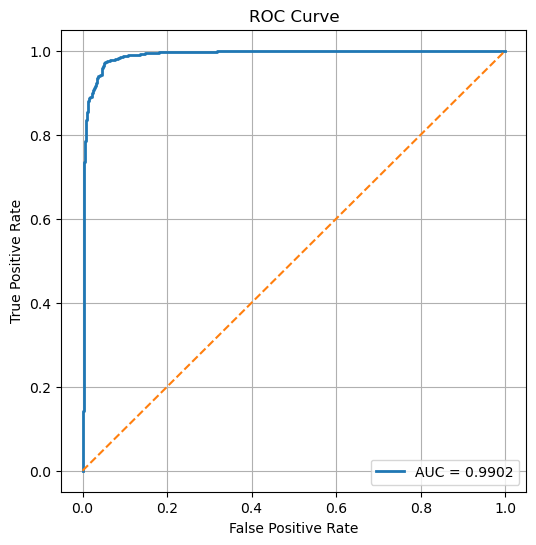

ROC-AUC Score: 0.9901861058855147


In [17]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Reset generator
val_gen.reset()

# Collect predictions safely
y_pred_prob = []
y_true = []

for i in range(len(val_gen)):
    x_batch, y_batch = val_gen[i]
    preds = model.predict(x_batch, verbose=0)
    
    # Store predictions properly - don't use ravel() which flattens all dimensions
    if len(preds.shape) > 1 and preds.shape[1] > 1:
        # For multi-class, store the whole prediction array
        y_pred_prob.extend(preds)
    else:
        # For binary with single output
        y_pred_prob.extend(preds.flatten())
        
    # Extend true labels
    y_true.extend(y_batch)

# Convert to numpy arrays
y_pred_prob = np.array(y_pred_prob)
y_true = np.array(y_true)

print("y_true length:", len(y_true))
print("y_pred length:", len(y_pred_prob))
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred_prob.shape)

# Convert multi-label format to binary format if needed
# If y_true is one-hot encoded, convert to class indices
if len(y_true.shape) > 1 and y_true.shape[1] > 1:
    y_true = np.argmax(y_true, axis=1)
    
# For binary classification, ensure we're using the probability of the positive class
if len(y_pred_prob.shape) > 1 and y_pred_prob.shape[1] > 1:
    y_pred_prob = y_pred_prob[:, 1]  # Use probability of positive class (index 1)

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", linewidth=2)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_true, y_pred_prob))

In [18]:
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix, classification_report
import pandas as pd
import seaborn as sns

def evaluate_model(model, model_name):

    val_gen.reset()

    y_pred_prob = []
    y_true = []

    for i in range(len(val_gen)):
        x_batch, y_batch = val_gen[i]
        preds = model.predict(x_batch, verbose=0)

        if len(preds.shape) > 1 and preds.shape[1] > 1:
            y_pred_prob.extend(preds[:,1])
        else:
            y_pred_prob.extend(preds.flatten())

        if len(y_batch.shape) > 1 and y_batch.shape[1] > 1:
            y_true.extend(np.argmax(y_batch, axis=1))
        else:
            y_true.extend(y_batch)

    y_pred_prob = np.array(y_pred_prob)
    y_true = np.array(y_true)

    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc = roc_auc_score(y_true, y_pred_prob)

    y_pred = (y_pred_prob > 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n===== {model_name} Results =====")
    print("AUC:", roc_auc)
    print(classification_report(y_true, y_pred))

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    return {
        "Model": model_name,
        "AUC": roc_auc,
        "Accuracy": np.mean(y_pred == y_true),
        "Precision": classification_report(y_true, y_pred, output_dict=True)['1']['precision'],
        "Recall": classification_report(y_true, y_pred, output_dict=True)['1']['recall'],
        "F1": classification_report(y_true, y_pred, output_dict=True)['1']['f1-score']
    }


===== MobileNetV3Large Results =====
AUC: 0.9929736629938188
              precision    recall  f1-score   support

           0       0.97      0.94      0.95      1220
           1       0.94      0.98      0.96      1220

    accuracy                           0.96      2440
   macro avg       0.96      0.96      0.96      2440
weighted avg       0.96      0.96      0.96      2440



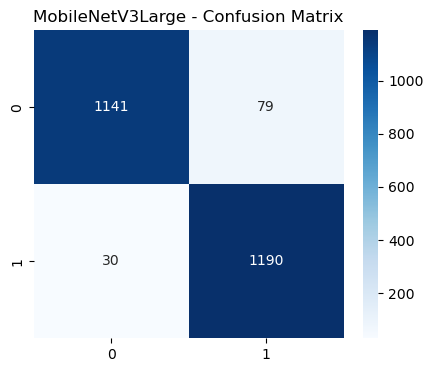

In [19]:
results = []
results.append(evaluate_model(model, "MobileNetV3Large"))

In [26]:
model.save("MobileNetV3Large_final.keras")

In [27]:
from tensorflow.keras.models import load_model
model = load_model("MobileNetV3Large_final.keras")

In [28]:
import pickle

with open("mobilenetv3_history.pkl", "wb") as f:
    pickle.dump({
        "stage1": history.history,
        "fine_tune": history_fine.history
    }, f)

In [29]:
import pickle

with open("mobilenetv3_history.pkl", "wb") as f:
    pickle.dump({
        "stage1": history.history,
        "fine_tune": history_fine.history
    }, f)

In [30]:
import numpy as np

np.save("mobilenetv3_confusion_matrix.npy", cm)

In [31]:
import pandas as pd

results_df = pd.DataFrame([{
    "Model": "MobileNetV3Large",
    "AUC": roc_auc,
    "Accuracy": np.mean(y_pred == y_true),
    "Precision": classification_report(y_true, y_pred, output_dict=True)['1']['precision'],
    "Recall": classification_report(y_true, y_pred, output_dict=True)['1']['recall'],
    "F1": classification_report(y_true, y_pred, output_dict=True)['1']['f1-score']
}])

results_df.to_csv("mobilenetv3_results.csv", index=False)

In [32]:
def train_new_model(base_model_class, name):

    base_model = base_model_class(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)   # <-- FIXED HERE
    )

    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)
    output = Dense(1, activation='sigmoid')(x)

    model_temp = Model(base_model.input, output)

    model_temp.compile(
        optimizer=Adam(learning_rate=3e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    model_temp.fit(
        train_gen,
        validation_data=val_gen,
        epochs=15,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    # Fine tuning
    base_model.trainable = True
    for layer in base_model.layers[:-40]:
        layer.trainable = False

    model_temp.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    model_temp.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    return model_temp


===== MobileNetV3Large Results =====
AUC: 0.9931510346681001
              precision    recall  f1-score   support

           0       0.98      0.93      0.95      1220
           1       0.93      0.98      0.96      1220

    accuracy                           0.96      2440
   macro avg       0.96      0.96      0.96      2440
weighted avg       0.96      0.96      0.96      2440



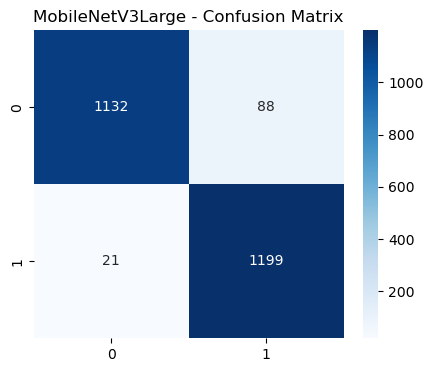

In [33]:
results = []

results.append(evaluate_model(model, "MobileNetV3Large"))

In [36]:
def train_new_model(base_model_class, name):

    import tensorflow as tf   # Safe inside function
    
    print(f"\nBuilding {name}...\n")

    # Build base model
    base_model = base_model_class(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )

    base_model.trainable = False

    # Custom classifier head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)   # Slightly stronger regularization
    output = Dense(1, activation='sigmoid')(x)

    model_temp = Model(inputs=base_model.input, outputs=output)

    # Compile Stage 1
    model_temp.compile(
        optimizer=Adam(learning_rate=3e-4),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc')
        ]
    )

    print(f"\nTraining {name} - Stage 1 (Frozen Base)\n")

    history_stage1 = model_temp.fit(
        train_gen,
        validation_data=val_gen,
        epochs=15,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    # Fine-tuning
    print(f"\nFine-Tuning {name}\n")

    base_model.trainable = True

    # Unfreeze last 30% of layers instead of fixed 40
    fine_tune_at = int(len(base_model.layers) * 0.7)

    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    model_temp.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc')
        ]
    )

    history_stage2 = model_temp.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    return model_temp, history_stage1, history_stage2

In [41]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=8,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    validation_split=0.2
)

In [42]:
print(train_gen.class_mode)
print(val_gen.class_mode)

categorical
categorical


In [43]:
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, model_name):

    print(f"\nEvaluating {model_name}...\n")

    val_gen.reset()

    y_pred_prob = []
    y_true = []

    # Collect predictions safely
    for i in range(len(val_gen)):
        x_batch, y_batch = val_gen[i]
        preds = model.predict(x_batch, verbose=0)

        # For softmax (2 outputs) → take probability of positive class
        y_pred_prob.extend(preds[:, 1])

        # Convert one-hot labels to class index
        y_true.extend(np.argmax(y_batch, axis=1))

    y_pred_prob = np.array(y_pred_prob)
    y_true = np.array(y_true)

    # ---- ROC ----
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc = roc_auc_score(y_true, y_pred_prob)

    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curve")
    plt.legend()
    plt.grid()
    plt.show()

    # ---- Confusion Matrix ----
    y_pred = (y_pred_prob > 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    report = classification_report(y_true, y_pred, output_dict=True)

    print(classification_report(y_true, y_pred))

    return {
        "Model": model_name,
        "AUC": roc_auc,
        "Accuracy": np.mean(y_pred == y_true),
        "Precision": report['1']['precision'],
        "Recall": report['1']['recall'],
        "F1": report['1']['f1-score']
    }

In [44]:
def train_new_model(base_model_class, name):

    import tensorflow as tf

    print(f"\nBuilding {name}...\n")

    base_model = base_model_class(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )

    base_model.trainable = False

    # ---- Classification Head ----
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    output = Dense(2, activation='softmax')(x)   # 2 neurons for categorical

    model_temp = Model(inputs=base_model.input, outputs=output)

    # ---- Stage 1 Compile ----
    model_temp.compile(
        optimizer=Adam(learning_rate=3e-4),
        loss='categorical_crossentropy',   # categorical now
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc')
        ]
    )

    print(f"\nTraining {name} - Stage 1\n")

    history_stage1 = model_temp.fit(
        train_gen,
        validation_data=val_gen,
        epochs=15,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    # ---- Fine-Tuning ----
    print(f"\nFine-Tuning {name}\n")

    base_model.trainable = True

    fine_tune_at = int(len(base_model.layers) * 0.7)

    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    model_temp.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',   # categorical again
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc')
        ]
    )

    history_stage2 = model_temp.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    return model_temp, history_stage1, history_stage2

In [45]:
from tensorflow.keras.applications import MobileNetV2, ResNet50, DenseNet121, EfficientNetB0

models_dict = {
    "MobileNetV2": MobileNetV2,
    "ResNet50": ResNet50,
    "DenseNet121": DenseNet121,
    "EfficientNetB0": EfficientNetB0
}


Evaluating MobileNetV3Large...



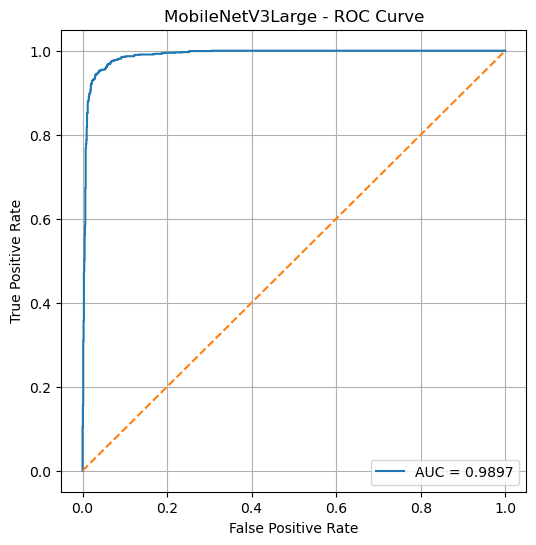

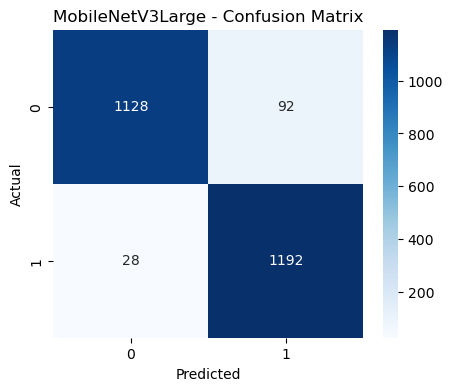

              precision    recall  f1-score   support

           0       0.98      0.92      0.95      1220
           1       0.93      0.98      0.95      1220

    accuracy                           0.95      2440
   macro avg       0.95      0.95      0.95      2440
weighted avg       0.95      0.95      0.95      2440



In [46]:
from tensorflow.keras.models import load_model

model_v3 = load_model("MobileNetV3Large_final.keras")

results.append(evaluate_model(model_v3, "MobileNetV3Large"))

In [47]:
# Keep best MobileNetV3Large result
v3_results = [r for r in results if r["Model"] == "MobileNetV3Large"]

if len(v3_results) > 1:
    best_v3 = max(v3_results, key=lambda x: x["AUC"])
    results = [r for r in results if r["Model"] != "MobileNetV3Large"]
    results.append(best_v3)

print("MobileNetV3Large cleaned.")

MobileNetV3Large cleaned.



Training MobileNetV2


Building MobileNetV2...


Training MobileNetV2 - Stage 1

Epoch 1/15
305/305 ━━━━━━━━━━━━━━━━━━━━ 546s 2s/step - accuracy: 0.6353 - auc: 0.6843 - loss: 0.7119 - val_accuracy: 0.8258 - val_auc: 0.9012 - val_loss: 0.4324 - learning_rate: 3.0000e-04
Epoch 2/15
305/305 ━━━━━━━━━━━━━━━━━━━━ 547s 2s/step - accuracy: 0.7238 - auc: 0.7959 - loss: 0.5609 - val_accuracy: 0.8393 - val_auc: 0.9133 - val_loss: 0.4038 - learning_rate: 3.0000e-04
Epoch 3/15
305/305 ━━━━━━━━━━━━━━━━━━━━ 519s 2s/step - accuracy: 0.7543 - auc: 0.8356 - loss: 0.5028 - val_accuracy: 0.8525 - val_auc: 0.9265 - val_loss: 0.3795 - learning_rate: 3.0000e-04
Epoch 4/15
305/305 ━━━━━━━━━━━━━━━━━━━━ 518s 2s/step - accuracy: 0.7778 - auc: 0.8585 - loss: 0.4701 - val_accuracy: 0.8340 - val_auc: 0.9159 - val_loss: 0.3943 - learning_rate: 3.0000e-04
Epoch 5/15
305/305 ━━━━━━━━━━━━━━━━━━━━ 519s 2s/step - accuracy: 0.7905 - auc: 0.8703 - loss: 0.4530 - val_accuracy: 0.8352 - val_auc: 0.9173 - val_loss: 0.3917 -

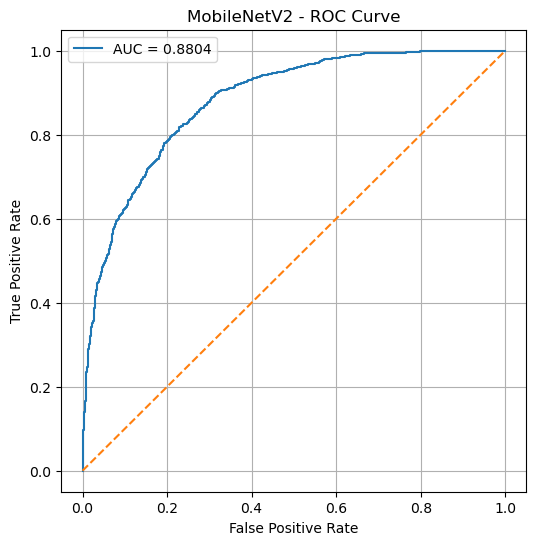

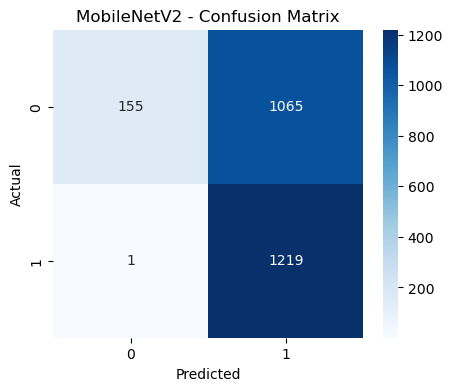

              precision    recall  f1-score   support

           0       0.99      0.13      0.23      1220
           1       0.53      1.00      0.70      1220

    accuracy                           0.56      2440
   macro avg       0.76      0.56      0.46      2440
weighted avg       0.76      0.56      0.46      2440


Training ResNet50


Building ResNet50...


Training ResNet50 - Stage 1

Epoch 1/15
305/305 ━━━━━━━━━━━━━━━━━━━━ 939s 3s/step - accuracy: 0.7277 - auc: 0.8011 - loss: 0.6293 - val_accuracy: 0.9152 - val_auc: 0.9722 - val_loss: 0.2306 - learning_rate: 3.0000e-04
Epoch 2/15
305/305 ━━━━━━━━━━━━━━━━━━━━ 943s 3s/step - accuracy: 0.8336 - auc: 0.9131 - loss: 0.3823 - val_accuracy: 0.9361 - val_auc: 0.9823 - val_loss: 0.1947 - learning_rate: 3.0000e-04
Epoch 3/15
305/305 ━━━━━━━━━━━━━━━━━━━━ 925s 3s/step - accuracy: 0.8638 - auc: 0.9361 - loss: 0.3251 - val_accuracy: 0.9311 - val_auc: 0.9814 - val_loss: 0.2038 - learning_rate: 3.0000e-04
Epoch 4/15
305/305 ━━━━━━━━━━━━━━

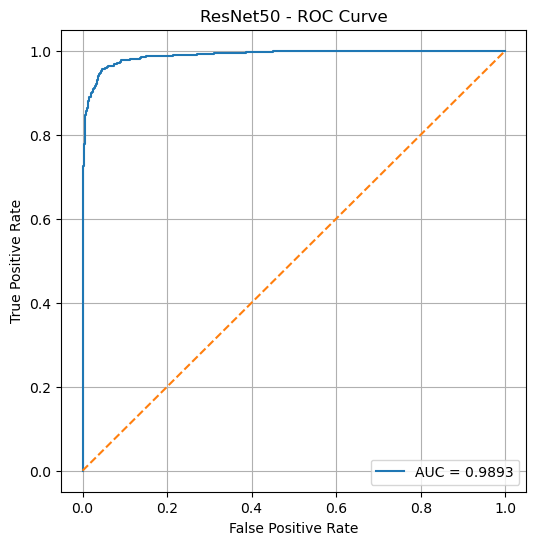

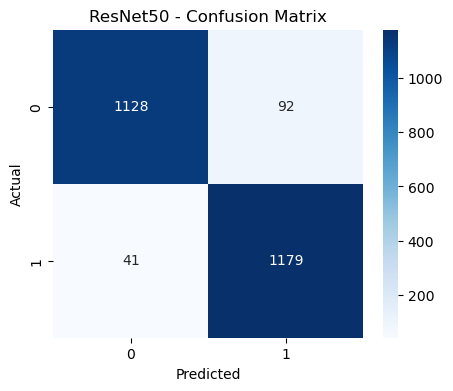

              precision    recall  f1-score   support

           0       0.96      0.92      0.94      1220
           1       0.93      0.97      0.95      1220

    accuracy                           0.95      2440
   macro avg       0.95      0.95      0.95      2440
weighted avg       0.95      0.95      0.95      2440


Training DenseNet121


Building DenseNet121...


Training DenseNet121 - Stage 1

Epoch 1/15
305/305 ━━━━━━━━━━━━━━━━━━━━ 16594s 54s/step - accuracy: 0.5663 - auc: 0.5844 - loss: 1.8691 - val_accuracy: 0.8127 - val_auc: 0.8821 - val_loss: 0.4723 - learning_rate: 3.0000e-04
Epoch 2/15
305/305 ━━━━━━━━━━━━━━━━━━━━ 1005s 3s/step - accuracy: 0.6836 - auc: 0.7442 - loss: 0.9120 - val_accuracy: 0.8311 - val_auc: 0.8972 - val_loss: 0.4247 - learning_rate: 3.0000e-04
Epoch 3/15
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7167 - auc: 0.7918 - loss: 0.6645
Epoch 3: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
305/305 ━━━━━━━━━━━━━━━━━━━━ 995s 

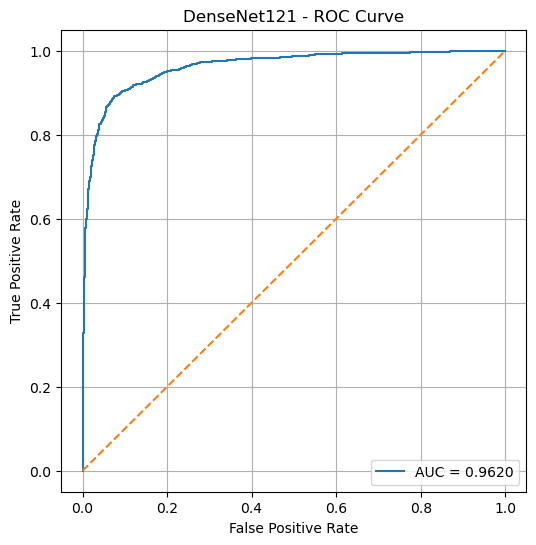

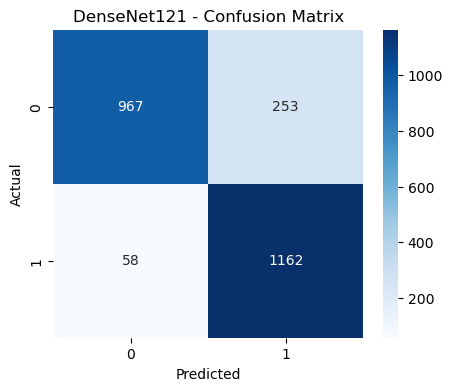

              precision    recall  f1-score   support

           0       0.94      0.79      0.86      1220
           1       0.82      0.95      0.88      1220

    accuracy                           0.87      2440
   macro avg       0.88      0.87      0.87      2440
weighted avg       0.88      0.87      0.87      2440


Training EfficientNetB0


Building EfficientNetB0...


Training EfficientNetB0 - Stage 1

Epoch 1/15
305/305 ━━━━━━━━━━━━━━━━━━━━ 584s 2s/step - accuracy: 0.7256 - auc: 0.8064 - loss: 0.5339 - val_accuracy: 0.9070 - val_auc: 0.9638 - val_loss: 0.3061 - learning_rate: 3.0000e-04
Epoch 2/15
305/305 ━━━━━━━━━━━━━━━━━━━━ 547s 2s/step - accuracy: 0.8290 - auc: 0.9093 - loss: 0.3879 - val_accuracy: 0.9193 - val_auc: 0.9739 - val_loss: 0.2706 - learning_rate: 3.0000e-04
Epoch 3/15
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8515 - auc: 0.9311 - loss: 0.3460
Epoch 3: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
305/305 ━━━━━━━━━━━━━━━━━━━━ 

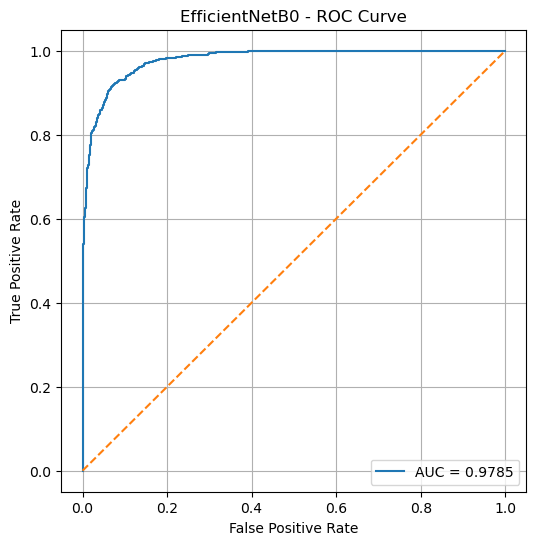

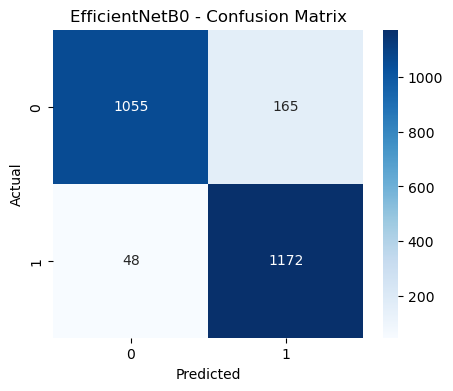

              precision    recall  f1-score   support

           0       0.96      0.86      0.91      1220
           1       0.88      0.96      0.92      1220

    accuracy                           0.91      2440
   macro avg       0.92      0.91      0.91      2440
weighted avg       0.92      0.91      0.91      2440



In [48]:
for name, architecture in models_dict.items():

    print("\n==============================")
    print(f"Training {name}")
    print("==============================\n")

    temp_model, hist1, hist2 = train_new_model(architecture, name)

    results.append(evaluate_model(temp_model, name))

In [49]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="AUC", ascending=False)

print("\n===== FINAL MODEL COMPARISON =====\n")
print(results_df)

best_model = results_df.iloc[0]

print("\n🏆 Best Model Based on AUC:")
print(best_model)


===== FINAL MODEL COMPARISON =====

              Model       AUC  Accuracy  Precision    Recall        F1
0  MobileNetV3Large  0.993151  0.955328   0.931624  0.982787  0.956522
2          ResNet50  0.989288  0.945492   0.927616  0.966393  0.946608
4    EfficientNetB0  0.978539  0.912705   0.876589  0.960656  0.916699
3       DenseNet121  0.961997  0.872541   0.821201  0.952459  0.881973
1       MobileNetV2  0.880364  0.563115   0.533713  0.999180  0.695776

🏆 Best Model Based on AUC:
Model        MobileNetV3Large
AUC                  0.993151
Accuracy             0.955328
Precision            0.931624
Recall               0.982787
F1                   0.956522
Name: 0, dtype: object


In [50]:
print(hist1.history.keys())

dict_keys(['accuracy', 'auc', 'loss', 'val_accuracy', 'val_auc', 'val_loss', 'learning_rate'])


In [54]:
print(dir())

['Adam', 'BATCH_SIZE', 'BatchNormalization', 'DATASET_PATH', 'Dense', 'DenseNet121', 'Dropout', 'EPOCHS', 'EarlyStopping', 'EfficientNetB0', 'GlobalAveragePooling2D', 'IMG_SIZE', 'ImageDataGenerator', 'In', 'MobileNetV2', 'MobileNetV3Large', 'Model', 'ModelCheckpoint', 'Out', 'ReduceLROnPlateau', 'ResNet50', '_', '_1', '_10', '_11', '_12', '_13', '_14', '_15', '_16', '_17', '_18', '_19', '_20', '_21', '_22', '_23', '_24', '_25', '_26', '_27', '_28', '_29', '_3', '_30', '_31', '_32', '_33', '_34', '_35', '_36', '_37', '_38', '_39', '_4', '_40', '_41', '_42', '_43', '_44', '_45', '_46', '_47', '_48', '_49', '_5', '_6', '_7', '_8', '_9', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__pandas', '__session__', '__spec__', '_dh', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i26', '_i27', '_i28', '_i29', '_i3', '_i30', '_i31', '_i32', '_i3

In [55]:
results_df.to_csv("model_comparison_results.csv", index=False)
print("Results table saved.")

Results table saved.


In [56]:
plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid()

plt.savefig("roc_curve.png")
plt.close()

print("ROC curve saved.")

ROC curve saved.


In [57]:
plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png")
plt.close()

print("Confusion matrix saved.")

Confusion matrix saved.


In [58]:
acc = hist1.history['accuracy'] + hist2.history['accuracy']
val_acc = hist1.history['val_accuracy'] + hist2.history['val_accuracy']

loss = hist1.history['loss'] + hist2.history['loss']
val_loss = hist1.history['val_loss'] + hist2.history['val_loss']

In [59]:
plt.figure(figsize=(6,4))
plt.plot(acc,label="Train Accuracy")
plt.plot(val_acc,label="Validation Accuracy")
plt.legend()
plt.grid()
plt.title("Accuracy Curve")
plt.savefig("accuracy_curve.png")
plt.close()

plt.figure(figsize=(6,4))
plt.plot(loss,label="Train Loss")
plt.plot(val_loss,label="Validation Loss")
plt.legend()
plt.grid()
plt.title("Loss Curve")
plt.savefig("loss_curve.png")
plt.close()

print("Training curves saved.")

Training curves saved.


In [62]:
import tensorflow as tf

model = tf.keras.models.load_model("MobileNetV3Large_final.keras")

print("Model loaded successfully")
model.summary()

Model loaded successfully


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ activation[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        256 │ re_lu[0][0]       │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_add   │ (None, 112, 112,  │          0 │ activation[0][0], │
│ (Add)               │ 16)               │            │ expanded_conv_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │      1,024 │ expanded_conv_ad… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ expanded_conv_1_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 113, 113,  │          0 │ re_lu_1[0][0]     │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        576 │ expanded_conv_1_… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        256 │ expanded_conv_1_

 Total params: 7,026,376 (26.80 MB)

 Trainable params: 1,874,658 (7.15 MB)

 Non-trainable params: 1,402,400 (5.35 MB)

 Optimizer params: 3,749,318 (14.30 MB)

In [70]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
import numpy as np

IMG_SIZE = (224,224)

def predict_mri(img_path):

    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)

    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)

    class_labels = {0:"Normal",1:"Sick"}
    predicted_class = np.argmax(pred)

    print("Prediction:", class_labels[predicted_class])
    print("Probabilities:", pred)

    return pred

In [72]:
pred = predict_mri(r"C:\Users\P.Srikar\Downloads\Final_Dataset\Sick\DC4.png")

print("Raw output:", pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
Prediction: Sick
Probabilities: [[6.698168e-07 9.999993e-01]]
Raw output: [[6.698168e-07 9.999993e-01]]


In [66]:
print(train_gen.class_indices)

{'Normal': 0, 'Sick': 1}


In [73]:
predict_mri(r"C:\Users\P.Srikar\Downloads\Final_Dataset\Normal\HC85.png")
predict_mri(r"C:\Users\P.Srikar\Downloads\Final_Dataset\Sick\DC4.png")
predict_mri(r"C:\Users\P.Srikar\Downloads\Final_Dataset\Sick\DC72.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
Prediction: Normal
Probabilities: [[0.9919132  0.00808675]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
Prediction: Sick
Probabilities: [[6.698168e-07 9.999993e-01]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
Prediction: Sick
Probabilities: [[1.6102078e-04 9.9983895e-01]]


array([[1.6102078e-04, 9.9983895e-01]], dtype=float32)

In [74]:
def predict_mri(img_path):

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)

    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)

    classes = ["Normal","Sick"]
    predicted = classes[np.argmax(pred)]

    return predicted, pred

In [78]:
predict_mri(r"C:\Users\P.Srikar\Downloads\Final_Dataset\Sick\DC89.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


('Sick', array([[0.00139534, 0.9986047 ]], dtype=float32))

In [6]:
import numpy as np
import cv2
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

In [7]:
model = load_model("best_heart_model.keras")

In [8]:
def predict_mri(img_path):

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)

    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)

    classes = ["Normal", "Sick"]
    predicted = classes[np.argmax(pred)]

    return predicted, pred

In [9]:
predict_mri(r"C:\Users\P.Srikar\Downloads\Final_Dataset\Normal\HC89.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


('Normal', array([[0.9784021 , 0.02159791]], dtype=float32))

In [10]:
predict_mri(r"C:\Users\P.Srikar\Downloads\Final_Dataset\Normal\HC208.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


('Normal', array([[0.9461853 , 0.05381475]], dtype=float32))

In [1]:
import numpy as np
import cv2
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

model = load_model("best_heart_model.keras")

def predict_mri(img_path):

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)

    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)

    classes = ["Normal", "Sick"]
    predicted = classes[np.argmax(pred)]

    return predicted, pred

In [2]:
predict_mri(r"C:\Users\P.Srikar\Downloads\Final_Dataset\Normal\HC2.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


('Normal', array([[0.6123812 , 0.38761878]], dtype=float32))

In [3]:
predict_mri(r"C:\Users\P.Srikar\Downloads\Final_Dataset\Normal\HC117.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


('Normal', array([[0.7814456 , 0.21855439]], dtype=float32))

In [4]:
predict_mri(r"C:\Users\P.Srikar\Downloads\Final_Dataset\Sick\DC106.png")
predict_mri(r"C:\Users\P.Srikar\Downloads\Final_Dataset\Sick\DC120.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


('Sick', array([[0.01012014, 0.98987985]], dtype=float32))

In [5]:
predict_mri(r"C:\Users\P.Srikar\Downloads\Final_Dataset\Normal\HC106.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


('Normal', array([[0.90534097, 0.09465902]], dtype=float32))

In [9]:
predict_mri(r"C:\Users\P.Srikar\Downloads\Final_Dataset\H_MRI_Test\HMRI1.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


('Sick', array([[0.10172591, 0.89827406]], dtype=float32))

In [12]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

model = load_model("best_heart_model.keras")

def predict_mri(img_path):

    img = image.load_img(img_path, target_size=(224,224))

    img_array = image.img_to_array(img)

    img_array = preprocess_input(img_array)

    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)

    classes = ["Normal", "Sick"]
    predicted_class = classes[np.argmax(pred)]

    print("Prediction:", predicted_class)
    print("Probabilities:", pred)

    return predicted_class

In [13]:
predict_mri(r"C:\Users\P.Srikar\Downloads\Final_Dataset\Sick\DC6000.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Prediction: Sick
Probabilities: [[1.8880179e-04 9.9981123e-01]]


'Sick'